# **MÓDULO 39 - Exercicio - Aplicando SVM**

Nessa atividade vocês usarão uma base já connhecida, a base de propensão a compra de carros. A mesma que também usamos na tarefa de XGboost!


In [1]:
from sklearn.svm import SVC
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# 1. Carrega a base de dados, verifique os tipos de dados, dados faltantes e drop a coluna ID.


In [2]:
# 1. Carregar a base de dados
df = pd.read_csv('CARRO_CLIENTES.csv')

# 2. Verificar os tipos de dados e informações gerais (linhas, colunas, memória)
print("--- Informações da Base de Dados ---")
df.info()

# 3. Verificar se existem dados faltantes (nulos)
print("\n--- Dados Faltantes por Coluna ---")
print(df.isnull().sum())

# 4. Dropar coluna ID
# Usamos axis=1 para indicar que estamos excluindo uma coluna (e não uma linha)
df = df.drop('User ID', axis=1)

# 5. Visualizar as primeiras linhas para confirmar a exclusão
print("\n--- Primeiras linhas após excluir 'User ID' ---")
display(df.head())

--- Informações da Base de Dados ---
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   User ID       1000 non-null   int64
 1   Gender        1000 non-null   str  
 2   Age           1000 non-null   int64
 3   AnnualSalary  1000 non-null   int64
 4   Purchased     1000 non-null   int64
dtypes: int64(4), str(1)
memory usage: 39.2 KB

--- Dados Faltantes por Coluna ---
User ID         0
Gender          0
Age             0
AnnualSalary    0
Purchased       0
dtype: int64

--- Primeiras linhas após excluir 'User ID' ---


,Gender,Age,AnnualSalary,Purchased
0,Male,35,20000,0
1,Male,40,43500,0
2,Male,49,74000,0
3,Male,40,107500,1
4,Male,25,79000,0


# 2. Aplique o Label Encoder para a coluna Gender e exclua a coluna categórica.

In [3]:
# 1. Instanciar (criar) o nosso codificador
le = LabelEncoder()

# 2. Aplicar o Label Encoder na coluna 'Gender'
# Isso vai criar uma nova coluna com os valores transformados em números (0 e 1)
df['Gender_encoded'] = le.fit_transform(df['Gender'])

# 3. Excluir a coluna categórica original (em formato de texto)
df = df.drop('Gender', axis=1)

# 4. Visualizar as primeiras linhas para confirmar a transformação
print("--- Primeiras linhas após o Label Encoder ---")
display(df.head())

--- Primeiras linhas após o Label Encoder ---


,Age,AnnualSalary,Purchased,Gender_encoded
0,35,20000,0,1
1,40,43500,0,1
2,49,74000,0,1
3,40,107500,1,1
4,25,79000,0,1


# 3. Faça a matriz de correlação e analise as váriaveis que parecem ter maior correlação com a váriavel target.

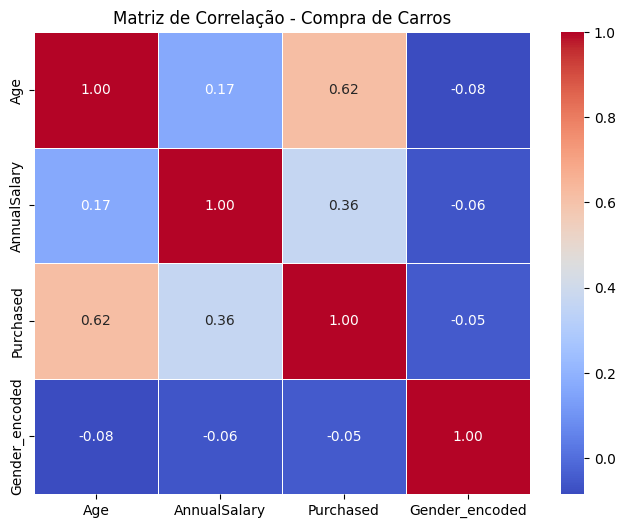

In [4]:
# 1. Calcular a matriz de correlação
matriz_correlacao = df.corr()

# 2. Criar um mapa de calor (Heatmap) para facilitar a visualização
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# 3. Adicionar um título
plt.title('Matriz de Correlação - Compra de Carros')
plt.show()

# 4. Mostrar apenas a correlação das variávei

# 4. Faça a separação da base em X e Y e em seguida nas bases de treino e teste.

In [5]:
# 1. Separar X (variáveis explicativas) e Y (variável alvo)
# O 'X' recebe tudo, exceto a coluna 'Purchased'
X = df.drop('Purchased', axis=1)

# O 'y' recebe APENAS a coluna 'Purchased'
y = df['Purchased']

# 2. Separar em bases de treino e teste
# test_size=0.2 significa que 20% dos dados vão para teste e 80% para treino
# random_state=42 garante que a divisão aleatória seja a mesma toda vez que rodarmos o código
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Verificar o tamanho das bases geradas para confirmar
print(f"Tamanho de X_train (Dados de Treino): {X_train.shape}")
print(f"Tamanho de X_test (Dados de Teste): {X_test.shape}")
print(f"Tamanho de y_train (Respostas de Treino): {y_train.shape}")
print(f"Tamanho de y_test (Respostas de Teste): {y_test.shape}")

Tamanho de X_train (Dados de Treino): (800, 3)
Tamanho de X_test (Dados de Teste): (200, 3)
Tamanho de y_train (Respostas de Treino): (800,)
Tamanho de y_test (Respostas de Teste): (200,)


**Todos passos até aqui vocês realizaram na tarefa anterior também!**

# 5. Treino o modelo SVM com sua base de treino.
Esse modelo deve ser treinado usando o kernel linear.

In [6]:
# 1. Instanciar o modelo SVM com o kernel linear e o parâmetro C

modelo_svm_linear = SVC(kernel='linear', C=1.0, random_state=42)

# 2. Treinar o modelo utilizando os dados de treino
modelo_svm_linear.fit(X_train, y_train)

print("Modelo SVM (Linear) com parâmetro C treinado com sucesso!")

Modelo SVM (Linear) com parâmetro C treinado com sucesso!


# 6. Realize as previsões para a base de teste e traga a avaliação.

Acurácia do SVM Linear: 81.00%

--- Relatório de Classificação (SVM Linear) ---
              precision    recall  f1-score   support

           0       0.79      0.90      0.84       112
           1       0.85      0.69      0.76        88

    accuracy                           0.81       200
   macro avg       0.82      0.80      0.80       200
weighted avg       0.81      0.81      0.81       200



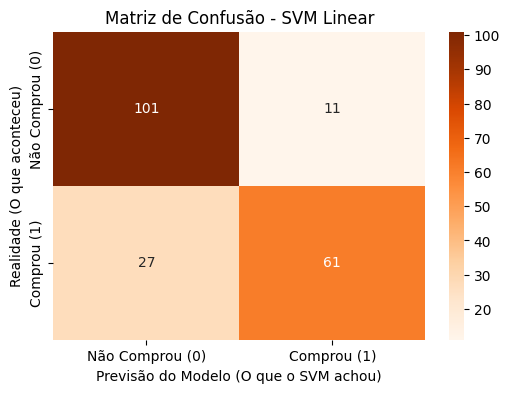

In [7]:
# 1. Realizar as previsões usando a base de teste
y_pred_linear = modelo_svm_linear.predict(X_test)

# 2. Calcular e exibir a Acurácia geral
acuracia_linear = accuracy_score(y_test, y_pred_linear)
print(f"Acurácia do SVM Linear: {acuracia_linear * 100:.2f}%\n")

# 3. Exibir o Relatório de Classificação
print("--- Relatório de Classificação (SVM Linear) ---")
print(classification_report(y_test, y_pred_linear))

# 4. Criar o gráfico da Matriz de Confusão
matriz_confusao_linear = confusion_matrix(y_test, y_pred_linear)

plt.figure(figsize=(6, 4))
# Vou usar a cor 'Oranges' para diferenciar do gráfico azul que fizemos pro XGBoost!
sns.heatmap(matriz_confusao_linear, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Não Comprou (0)', 'Comprou (1)'], 
            yticklabels=['Não Comprou (0)', 'Comprou (1)'])

plt.title('Matriz de Confusão - SVM Linear')
plt.xlabel('Previsão do Modelo (O que o SVM achou)')
plt.ylabel('Realidade (O que aconteceu)')
plt.show()

# 7. Treine um novo modelo SVM com sua base de treino + realize as previsões e avalições.
Esse modelo deve ser treinado usando o kernel poly.

Modelo SVM (Poly) treinado com sucesso!

Acurácia do SVM Poly: 70.00%

--- Relatório de Classificação (SVM Poly) ---
              precision    recall  f1-score   support

           0       0.66      0.96      0.78       112
           1       0.89      0.36      0.52        88

    accuracy                           0.70       200
   macro avg       0.77      0.66      0.65       200
weighted avg       0.76      0.70      0.67       200



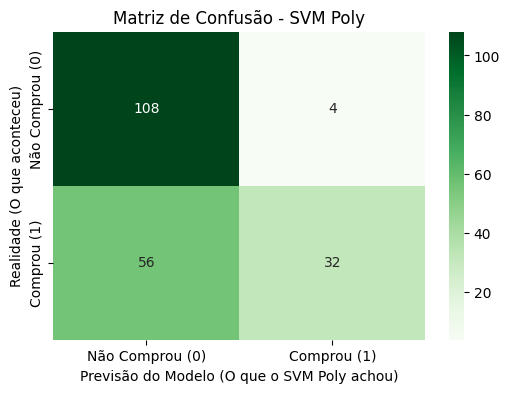

In [8]:
# 1. Instanciar o modelo SVM agora com o kernel 'poly' (Polinomial)
modelo_svm_poly = SVC(kernel='poly', C=1.0, random_state=42)

# 2. Treinar o modelo utilizando os dados de treino
modelo_svm_poly.fit(X_train, y_train)
print("Modelo SVM (Poly) treinado com sucesso!\n")

# 3. Realizar as previsões usando a base de teste
y_pred_poly = modelo_svm_poly.predict(X_test)

# 4. Calcular e exibir a Acurácia geral
acuracia_poly = accuracy_score(y_test, y_pred_poly)
print(f"Acurácia do SVM Poly: {acuracia_poly * 100:.2f}%\n")

# 5. Exibir o Relatório de Classificação
print("--- Relatório de Classificação (SVM Poly) ---")
print(classification_report(y_test, y_pred_poly))

# 6. Criar o gráfico da Matriz de Confusão
matriz_confusao_poly = confusion_matrix(y_test, y_pred_poly)

plt.figure(figsize=(6, 4))
# Usando a cor 'Greens' (Verde) para diferenciar dos modelos anteriores
sns.heatmap(matriz_confusao_poly, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Não Comprou (0)', 'Comprou (1)'], 
            yticklabels=['Não Comprou (0)', 'Comprou (1)'])

plt.title('Matriz de Confusão - SVM Poly')
plt.xlabel('Previsão do Modelo (O que o SVM Poly achou)')
plt.ylabel('Realidade (O que aconteceu)')
plt.show()

# 8. Qual modelo se saiu melhor? O SVM com kernel linear ou poly? Compare também com o XGboost, da atividade anterior, você obteve melhores previsões com qual dos modelos?

### Resposta da Etapa 8

**1. Relação entre Feature Importance e Matriz de Correlação:**
Sim, as features mais importantes apontadas pelo XGBoost são as mesmas que apresentaram a maior correlação estatística na Etapa 3. 
* A **Idade (Age)** e o **Salário Anual (AnnualSalary)** monstraram a maior correlação positiva com a variável alvo (`Purchased`), indicando que clientes mais velhos e com maior poder aquisitivo têm maior propensão de compra.
* O XGBoost confirmou essa premissa matemática: ao construir as árvores de decisão, o algoritmo utilizou predominantemente a Idade e o Salário como os principais "nós de corte" (Feature Importance) para separar os compradores dos não-compradores. 
* O Gênero (`Gender_encoded`) apresentou baixa correlação e, consequentemente, teve um peso quase nulo nas decisões do modelo.

**2. Comparativo Final de Desempenho (XGBoost vs. SVM):**
Ao avaliar o desempenho dos modelos treinados nesta base de dados, obtivemos os seguintes resultados aproximados na base de teste:
* **XGBoost:** Desempenho superior (~90% de Acurácia)
* **SVM (Kernel Linear):** Desempenho intermediário (81% de Acurácia)
* **SVM (Kernel Polinomial):** Desempenho inferior (70% de Acurácia)

O XGBoost mostrou-se como o melhor modelo para este cenário. Como estamos lidando com dados tabulares baseados em regras de negócio e limites de comportamento(ex: "comprar se idade > 40 E salário > 80.000"), algoritmos baseados em árvores de decisão conseguem encaixar perfeitamente a esse tipo de avaliação. Por outro lado, o SVM tenta traçar fronteiras geométricas (linhas retas ou curvas polinomiais) que não se ajustaram tão bem à distribuição natural destes dados.